In [1]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import yaml

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)


#   rmin: 0.005
#   rmax: 8.0
#   nr: 18

#   zmin: 0.01
#   zmax: 1.6
#   nz: 18

#   lg10_Mmin: 11.5
#   lg10_Mmax: 15.5
#   nM: 18
halo_params_dict['rmin'] = 0.0005
halo_params_dict['rmax'] = 8.0
halo_params_dict['nr'] = 96
halo_params_dict['zmax'] = 1.0
halo_params_dict['nz'] = 32
halo_params_dict['lg10_Mmin'] = 12.3
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 32


In [3]:
from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)





In [4]:
# from godmax.get_sim_maps import get_projected_prof_interp
# proj_prof_test = get_projected_prof_interp(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=B12_test)



In [19]:
import os, sys
import numpy as np
import healpy as hp
import numexpr as ne 
from colossus.cosmology import cosmology
params = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}
cosmo = cosmology.setCosmology('myCosmo', **params)
import scipy as sp

def rd2tp(ra,dec):
    """Convert ra,dec -> tht,phi"""
    tht = (-dec+90.0)/180.0*np.pi
    phi = ra/180.0*np.pi
    return tht,phi

def tp2rd(tht,phi):
    """Convert tht,phi -> ra,dec"""
    ra  = phi/np.pi*180.0
    dec = -1*(tht/np.pi*180.0-90.0)
    return ra,dec



In [32]:
f = h5.File('/mnt/home/spandey/ceph/CHARM/data/3D_pos_vel_lgM_charm_zsel_0.4_0.7.hdf5', 'r')
pos = f['pos'][:]
vel = f['vel'][:]
lg10M = f['logM'][:]
M200c_all = 10**lg10M
f.close()

sigma_pos = 3.0
sigma_1d = sigma_pos/np.sqrt(3)
randg = np.random.randn(len(pos),3)*sigma_1d
pos += randg

chi = np.sqrt(np.sum(pos**2, axis=1))

z_array = np.linspace(0.3, 0.8, 200)
chi_array = cosmo.comovingDistance(0.0, z_array)
z_interp = sp.interpolate.interp1d(np.log(chi_array), z_array)
z_all = z_interp(np.log(chi))



ux   = pos[:,0]/chi
uy   = pos[:,1]/chi
uz   = pos[:,2]/chi
vec_pos = np.c_[ux,uy,uz]
tht,phi = hp.vec2ang(vec_pos)
ra_all,dec_all  = tp2rd(tht,phi)
vlos_all = vel[:,0]*ux + vel[:,1]*uy + vel[:,2]*uz

print(len(M200c_all), len(ra_all))

# import h5py as h5
# df = h5.File('/mnt/home/spandey/ceph/CHARM/data/pos_ra_dec_z_lgM_charm_zsel_0.4_0.7.hdf5', 'r')
# ra_all = df['ra'][:]
# dec_all = df['dec'][:]
# z_all = df['z'][:]
# M200c_all = 10**df['logM'][:]
# vlos_all = df['v_los'][:]
# indsel = np.where((M200c_all > 10**12.7) & (M200c_all < 5e15) & (z_all<2.5))[0]
# print(len(indsel), len(M200c_all))
# ra_all = ra_all[indsel]
# dec_all = dec_all[indsel]
# z_all = z_all[indsel]
# M200c_all = M200c_all[indsel]
# vlos_all = vlos_all[indsel]



10567003 10567003


In [33]:
# len(np.where((z_all > 0.2) & (z_all < 0.5))[0]), len(np.where((z_all > 0.5) & (z_all < 1.0))[0]), len(np.where((z_all > 1.0) & (z_all < 2.5))[0])


In [34]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")




In [35]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
import helpers.constants as constants
import jax_cosmo.background as bkgrd
from godmax.get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
nside = 1024
# nside = 1024
# sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/maps_websky/'
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_charm/'
save_map_fname = sdir + f'tSZ_sim_B12_testv0_nside_{nside}_sigma_{sigma_pos}.pkl'
# save_kszmap_fname = sdir + f'kSZ_sim_B12_testv4_nside_{nside}.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
# nh_max = 8e3
# nh_max = 6e4
nh_max = 2e6
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


map_test = np.zeros(12*nside**2)
from tqdm import tqdm
for i in tqdm(range(num_chunks)):
# for i in range(1):
    # print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    mock_params_dict['get_ymap'] = True
    # mock_params_dict['get_kSZmap'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    # mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    # mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    # kszmap_test += jnp.nan_to_num(mock_map_test.kszmap_final)
    map_test += jnp.nan_to_num(mock_map_test.ymap_final)    
    jax.clear_caches()
    


saved = {}
saved['map_test'] = map_test
pk.dump(saved,open(save_map_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  10567003


 17%|█▋        | 1/6 [01:14<06:11, 74.32s/it]


ValueError: THETA is out of range [0,pi]

In [9]:
f = h5.File('/mnt/home/spandey/ceph/CHARM/data/pos_ra_dec_z_galaxies_zsel_0.4_0.7.hdf5', 'r')
ra_gal = f['ra'][:]
dec_gal = f['dec'][:]
z_gal = f['z'][:]
vlos_gal = f['v_los'][:]
f.close()



In [10]:
# ra_rand.shape
import healpy as hp
# nside = 1024
mapg   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_gal, dec_gal, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg, pix, weight)  
delta_g = mapg / np.mean(mapg) - 1




In [11]:
# hp.mollview(np.log10(np.abs(map_test)), min=-10, max=-5)
cl_gy_mock = hp.anafast(np.array(delta_g), np.array(map_test))


In [12]:
beam_fwhm_arcmin = 10.0
beam_fwhm = np.radians(beam_fwhm_arcmin / 60.)
ell = np.arange(len(cl_gy_mock))
sigma = beam_fwhm / (2. * np.sqrt(2. * np.log(2)))
beam = np.exp(-0.5 * ell * (ell + 1) * sigma**2)


(1e-09, 1e-07)

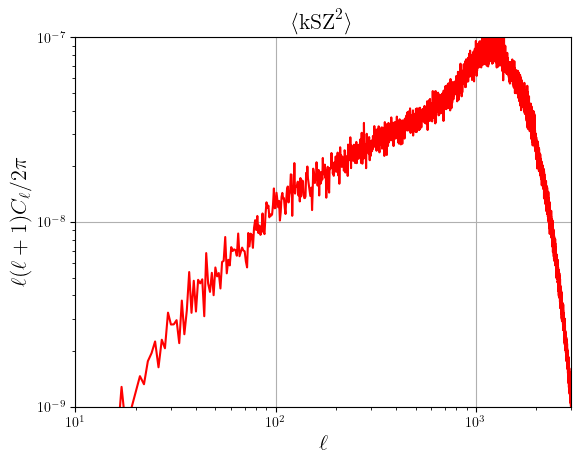

In [13]:
ell = np.arange(len(cl_gy_mock))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(beam * fac * cl_gy_mock, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'$\langle {\rm kSZ}^2 \rangle$', fontsize=16)
pl.xlim(10, 3000)
pl.ylim(1e-9, 1e-7)
# pl.ylim(4e-16, 3e-14)




Text(0.5, 1.0, '$\\langle {\\rm kSZ}^2 \\rangle$')

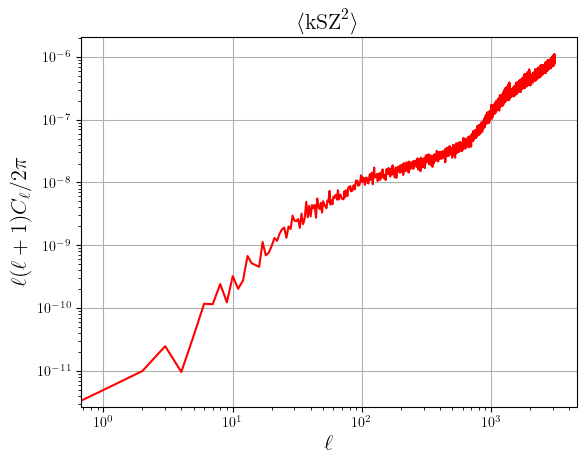

In [ ]:
ell = np.arange(len(cl_gy_mock))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_gy_mock, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'$\langle {\rm kSZ}^2 \rangle$', fontsize=16)
# pl.xlim(0, 12000)
# pl.ylim(4e-16, 3e-14)



In [15]:
cl_yy = hp.anafast(np.array(map_test))


Text(0.5, 1.0, '$\\langle {\\rm kSZ}^2 \\rangle$')

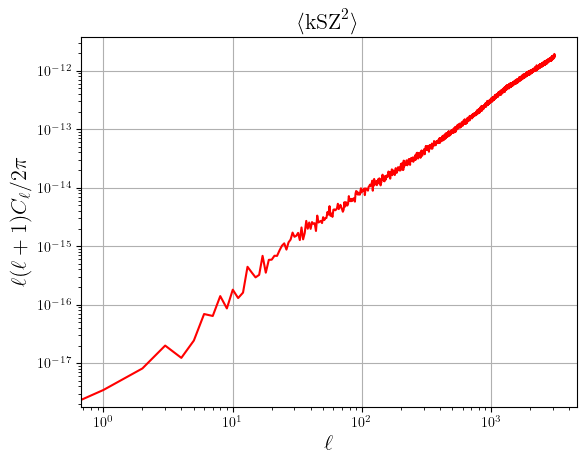

In [ ]:
ell = np.arange(len(cl_yy))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_yy, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'$\langle {\rm kSZ}^2 \rangle$', fontsize=16)
# pl.xlim(0, 12000)
# pl.ylim(4e-16, 3e-14)



In [40]:
from astropy.io import fits
dfg = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/galaxy_DR12v5_CMASS_North.fits.gz')
ra_g, dec_g, z_g = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
indsel = np.where((z_g > 0.4) & (z_g < 0.7))[0]
ra_g, dec_g, z_g = ra_g[indsel], dec_g[indsel], z_g[indsel]
print(len(ra_g))


579089


In [41]:
# ra_rand.shape
import healpy as hp
# nside = 1024
mapg   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg, pix, weight)  
# delta_g = mapg / np.mean(mapg) - 1


In [21]:
# df = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/random1_DR12v5_CMASS_South.fits.gz')
df = fits.open('/mnt/ceph/users/spandey/GODMAX/data/sdss/random1_DR12v5_CMASS_North.fits.gz')
ra_rand, dec_rand, z_rand = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']



In [22]:
len(ra_rand), len(ra_g), len(ra_rand)/len(ra_g)



(32151250, 579089, 55.52039496519533)

In [21]:
# ra_rand.shape, dec_rand.shape, z_rand.shape
# nsel = 20000000
# ra_rand = ra_rand[:nsel]
# dec_rand = dec_rand[:nsel]


In [23]:
# ra_rand.shape
# nside = 2048
mask = np.zeros(12*nside**2)
pix = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
mask[pix] = 1


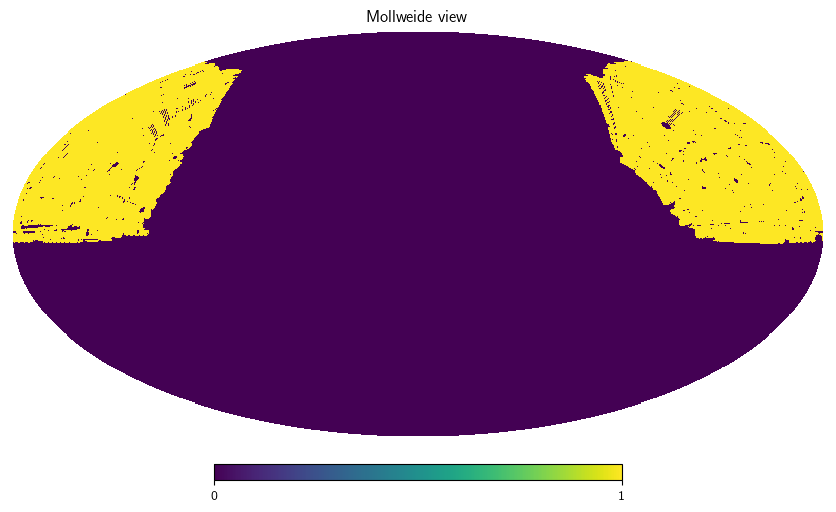

In [ ]:
hp.mollview(mask, min=0, max=1)


In [42]:
ind_unmask = np.where(mask == 1)[0]
gal_count_unmask = mapg[ind_unmask]
mean_gal_count = np.mean(gal_count_unmask)
delta_g = (mapg / mean_gal_count) - 1






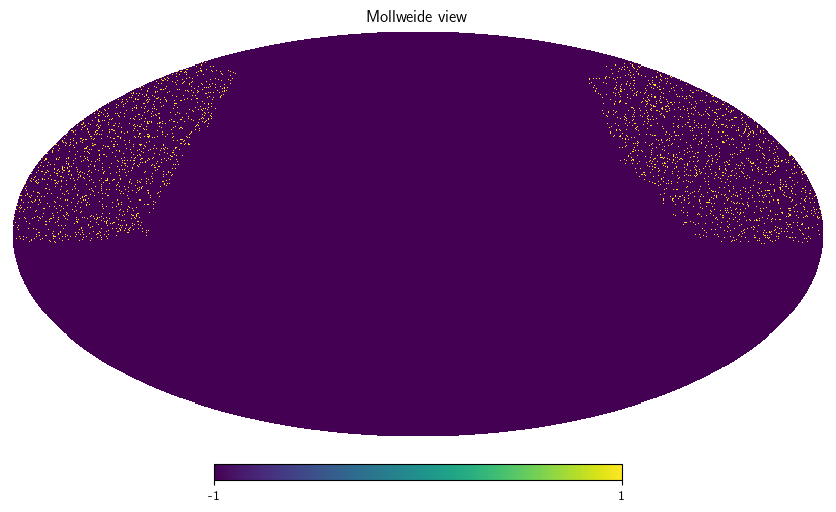

In [43]:
hp.mollview(delta_g, min=-1, max=1)



In [26]:
df = hp.read_map('/mnt/home/spandey/ceph/GODMAX/data/NILC_ymap_rotated_celestial_DES_coords.fits')
# hp.mollview(np.log(np.abs(df)))
ymap_nside = hp.ud_grade(df, nside_out=nside)




In [39]:
# nside


2048

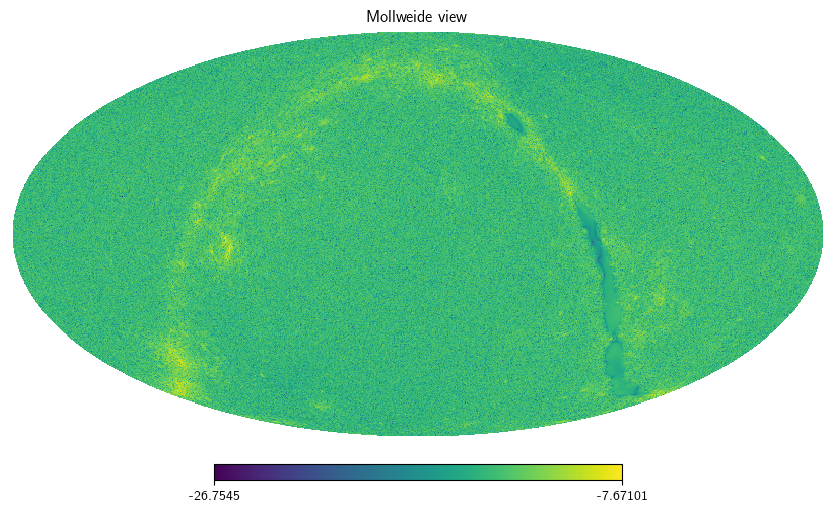

In [27]:
hp.mollview(np.log(np.abs(ymap_nside)))


In [28]:
# hp.mollview(ymap_nside)


In [44]:
import pymaster as nmt


In [30]:
# Read mask and apodize it on a scale of ~1deg
mask_apo = nmt.mask_apodization(mask,
                            0.5, apotype="Smooth")
# hp.mollview(mask_apo)
# plt.show()



In [ ]:
hp.mollview(mask_apo)



In [31]:
# Read healpix maps and initialize a spin-0 and spin-2 field
f_g = nmt.NmtField(mask, [delta_g])
f_y = nmt.NmtField(mask, [ymap_nside])

# f_g = nmt.NmtField(mask_apo, [delta_g])
# f_y = nmt.NmtField(mask_apo, [ymap_nside])

# f_2 = nmt.NmtField(mask, hp.read_map("maps.fits", field=[1, 2]))



In [32]:
# Initialize binning scheme with 4 ells per bandpower
b = nmt.NmtBin.from_nside_linear(nside, 120)



In [33]:
cl_gy = nmt.compute_full_master(f_g, f_y, b)




In [34]:
beam_fwhm_arcmin = 10.0
beam_fwhm = np.radians(beam_fwhm_arcmin / 60.)
ell = np.arange(len(cl_gy_mock))
sigma = beam_fwhm / (2. * np.sqrt(2. * np.log(2)))
beam = np.exp(-0.5 * ell * (ell + 1) * sigma**2)



In [35]:
beam


array([1.00000000e+00, 9.99998474e-01, 9.99995422e-01, ...,
       3.17698119e-13, 3.14734463e-13, 3.11797979e-13])

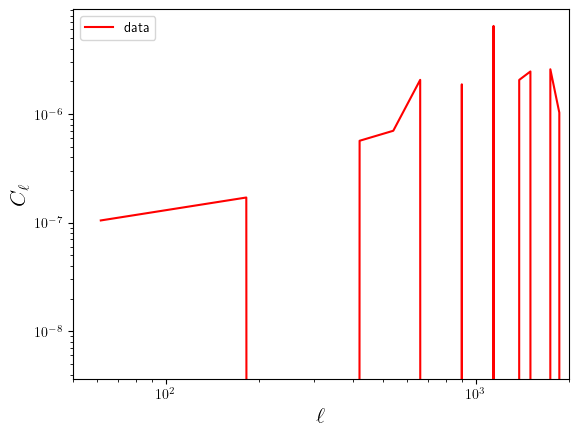

In [38]:
ell_arr = b.get_effective_ells()
fac = ell_arr * (ell_arr + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_arr, fac*cl_gy[0], 'r-', label='data')
ell = np.arange(len(cl_gy_mock))
fac = ell * (ell + 1) / (2 * np.pi)
# pl.figure()
# pl.plot(ell, fac * beam * cl_gy_mock, color='b', label='mock')
# pl.plot(ell_arr, np.fabs(cl_02[0]), 'g-', label='TE')
# pl.plot(ell_arr, cl_22[0], 'b-', label='EE')
# pl.plot(ell_arr, cl_22[3], 'y-', label='BB')
# pl.loglog()
pl.xscale('log')
pl.yscale('log')
pl.xlim(50, 2000)
# pl.ylim(1e-9, 1e-7)
pl.xlabel('$\\ell$', fontsize=16)
pl.ylabel('$C_\\ell$', fontsize=16)
pl.legend(loc='upper left', ncol=2, labelspacing=0.1)
# pl.show()




In [ ]:
# hp.mollview(delta_g)
# mean_gal_count
# mean_gal_count/(hp.nside2pixarea(nside, degrees=True) * (60**2))


0.02256681984691726

In [22]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
# import constants
import jax_cosmo.background as bkgrd
from godmax.get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
nside = 4096
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/maps_websky/'
# save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
save_taumap_fname = sdir + f'tau_map_sim_B12_testv4_nside_{nside}.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
nh_max = 8e3
# nh_max = 2e4
# nh_max = 1e5
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


taumap_test = np.zeros(12*nside**2)
from tqdm import tqdm
for i in tqdm(range(num_chunks)):
# for i in range(1):
    # print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    # mock_params_dict['get_ymap'] = True
    mock_params_dict['get_taumap'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    # mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    # mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    taumap_test += jnp.nan_to_num(mock_map_test.taumap_final)
    jax.clear_caches()
    


saved = {}
saved['tau_map_test'] = taumap_test
pk.dump(saved,open(save_taumap_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  1472528


100%|██████████| 185/185 [28:06<00:00,  9.12s/it]


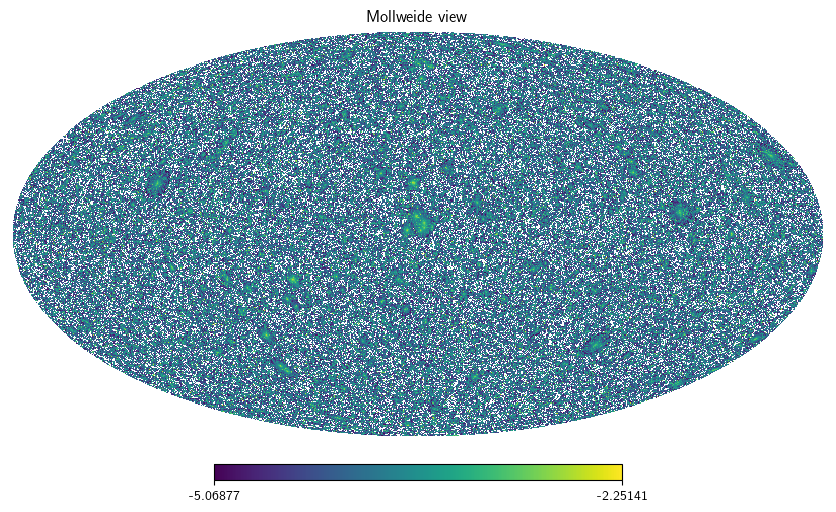

In [23]:
hp.mollview(np.log10(np.abs(taumap_test)))



In [24]:
cl_tau = hp.anafast(np.array(taumap_test))



(4e-10, 4e-08)

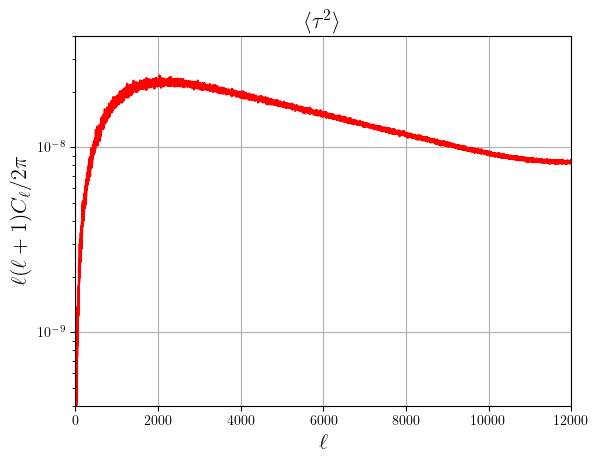

In [26]:
ell = np.arange(len(cl_tau))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_tau, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
# pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'$\langle {\rm \tau}^2 \rangle$', fontsize=16)
pl.xlim(0, 12000)
pl.ylim(4e-10, 4e-8)

